In [1]:
from agnpy.emission_regions import Cone
import astropy.units as u
from agnpy.spectra import ParticleDistribution
from agnpy.utils.conversion import nu_to_epsilon_prime, B_to_cgs, lambda_c_e, mec2
from agnpy.spectra.spectra import ExpCutoffPowerLaw
from agnpy.synchrotron import *
from scipy.interpolate import interp1d
from scipy.integrate import cumulative_trapezoid
import numpy as np
from astropy.constants import c, sigma_T, m_e, e, mu0
#e = e.gauss
import matplotlib.pyplot as plt

*Parameters used in Potter and Cotter to fit the BL Lac (Table 1)*

In [2]:
# Parameters used in Table 1 of Potter and Cotter; Fitting BL Lac (abdo et al. 2011)
z=0.0686
B_o = (3.63 * 1e-5 * u.T).to(u.G)
W_j = 7.63 * 1e36 * u.W
L = (1e19 * u.m).to(u.cm)
theta_open = 9.7 * u.deg
Gamma = 12
theta_s = 2 * u.deg
A_equi = 1.0
# Electron Distribution imposed by Potter and Cotter
p = 2
gamma_minimum = (5.11 * 1e6 * u.eV / mec2.to("eV")).value
gamma_maximum = (5.6 * 1e9 * u.eV / mec2.to("eV")).value
"""The normalization parameter is left to default, eq (7) in C. & P. leads to norm = 0? since alpha = 2"""
n_e = ExpCutoffPowerLaw(k=100, p = p, gamma_min = 0.1*gamma_minimum, gamma_max= 100*gamma_maximum, gamma_c= gamma_maximum )

In [3]:
jet = Cone(B_o = B_o, W_j = W_j, L = L, theta = theta_open, Gamma=Gamma, n_e = n_e,x_size=500,gamma_e_size=500, z =z)
jet.set_delta_D(Gamma=Gamma,theta_s = theta_s)

Formula used by Cotter and Potter (equation 8) yields the same R_o but in the Parameter table, R_o is mentioned as 7.32 * 1e13 m 
which (coincidentally?) is compatible with our jet with W_j = 0.1* W_j

In [4]:
jet.R_o

<Quantity 2.31629592e+16 cm>

In [5]:
Ro_using_cotter = (np.sqrt((2 *mu0 * 7.63 * 1e36 * u.W ) / (2 * c * 144 * np.pi * (3.63 * 1e-5 * u.T)**2 ))).to('m')
Ro_using_cotter

<Quantity 2.31629592e+14 m>

# Plots 

In [6]:
coordinates = [
    (585945.3915069195, 6.65905647933771e+45),
    (1180320.6356517298, 3.6753441641809446e+45),
    (2421029.04673618, 1.8950291465743076e+45),
    (5861381.645140285, 8.435148160601475e+44),
    (14454397.70745931, 3.481142923888426e+44),
    (23768402.866248783, 2.075324880373661e+44),
    (46989410.860521704, 1.1534180805525196e+44),
    (147231250.24327165, 3.8169973137017866e+43),
    (325087297.38543606, 1.693846972334023e+43),
    (831763771.1026742, 6.485157528062233e+42),
    (1614358556.8264935, 2.865619626947542e+42),
    (3076096814.7407174, 1.1725707943387419e+42),
    (5445026528.424242, 4.4349366153056454e+41),
    (10964781961.43192, 7.858944800779638e+40),
    (18030177408.59577, 1.2817831835790027e+40),
    (28575905433.749672, 1.2244668158998756e+39),
    (39084089579.24041, 1.164019524379192e+38),
    (59703528658.38415, 2.0753248803736612e+36),
    (89536476554.96011, 4.373153302721358e+33),
    (109647819614.31963, 7.740013565615246e+31),
    (129419584144.9997, 1.4766294411828247e+30)
]
x_data, y_data = zip(*coordinates)

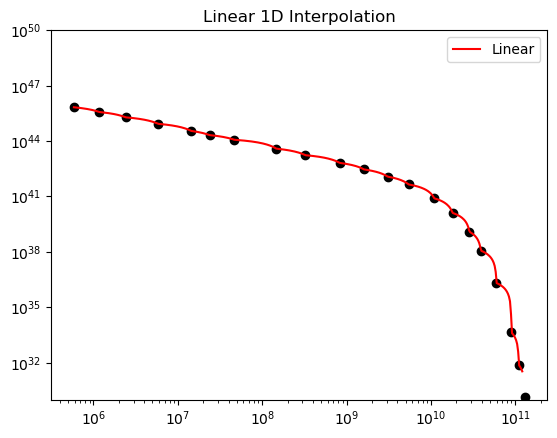

In [7]:
energy = (mec2.cgs * jet.gamma_e).to('eV')
linear_interp = interp1d(x_data, y_data, kind="linear")  # degree = number of points - 1
y_linear = linear_interp(energy.value[5:445])

plt.scatter(x_data, y_data, color="black")
plt.loglog(energy.value[5:445], y_linear, label="Linear", color="red")
plt.legend(); plt.title("Linear 1D Interpolation")
plt.ylim(1e30,1e50)
plt.show()

The following plot shows how energy is distributed among electrons, because high-energy electrons carry more energy. This is to show which energies dominate the total electron energy.


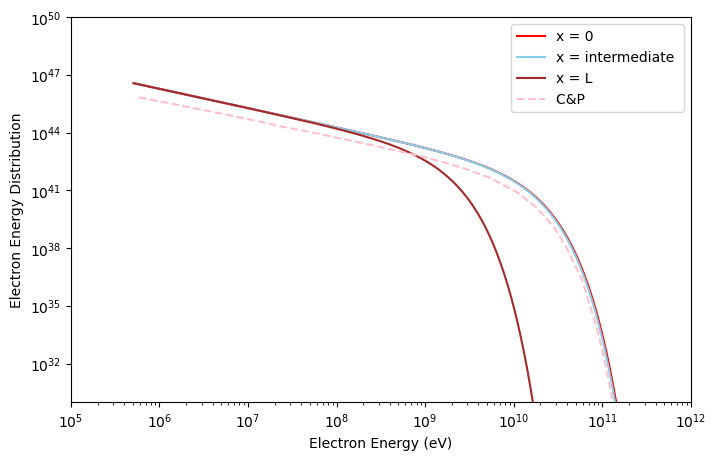

In [10]:
plt.figure(figsize=(8,5))
#for i, _n_e_g in enumerate(jet.N_e_xg[::20]):
    #plt.loglog((mec2*jet.gamma_e).to('eV'), jet.gamma_e*3*1e10*_n_e_g, label=f"x={i}",linestyle='dashed')
plt.loglog((mec2*jet.gamma_e).to('eV'), jet.gamma_e*(c.cgs.value)* jet.N_e_xg[0,:] , label="x = 0 ",linestyle='-',color='red')
plt.loglog((mec2*jet.gamma_e).to('eV'), jet.gamma_e*(c.cgs.value)*jet.N_e_xg[349,:] , label="x = intermediate ",linestyle='-',color='skyblue')
plt.loglog((mec2*jet.gamma_e).to('eV'), jet.gamma_e*(c.cgs.value)* jet.N_e_xg[-1,:] , label="x = L ",linestyle='-',color='brown')
plt.loglog(x_data, y_data, label=f"C&P ",linestyle='dashed',color='pink')
#plt.plot((mec2*jet.gamma_e).to('eV'), jet.norm_equi*3*1e10*jet.N_e_base)
plt.xlabel('Electron Energy (eV)')
plt.ylabel('Electron Energy Distribution')
plt.legend()
plt.xlim(1e5,1e12)
plt.ylim(1e30,1e50)
plt.show()

In [95]:
n0 = jet.norm_equi * jet.N_e_base[None,:] # (1, N_gamma)
int_B = cumulative_trapezoid((jet.B_x)**2, jet.x, initial=0) # (N_x, 1)
cooling = ( sigma_T.cgs * jet.gamma_e[None,:] *(int_B[:,None])) / ( 6 * np.pi * mec2.cgs )

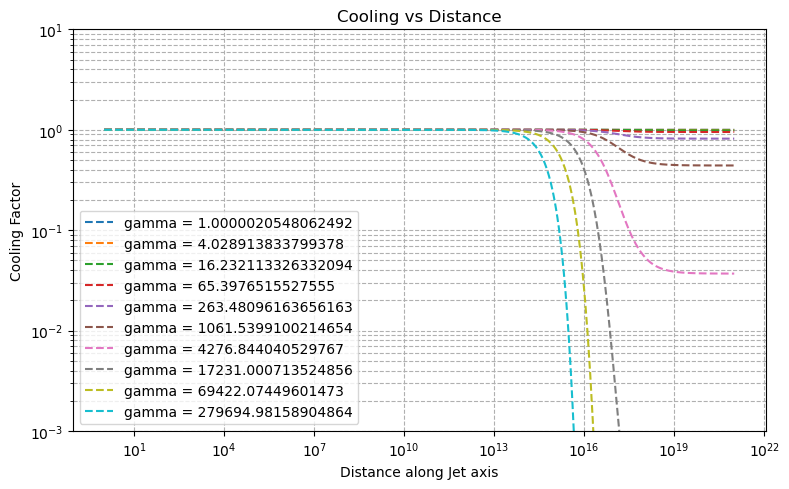

In [51]:
plt.figure(figsize=(8,5))
# Select every 70th gamma column, then transpose so we can iterate over columns
for i, cooling_gamma in enumerate(np.exp(-cooling.value[:, ::50].T)):
    plt.loglog(jet.x, cooling_gamma, label=f'gamma = {jet.gamma_e[50*i]}',linestyle='dashed')
plt.xlabel("Distance along Jet axis")
plt.ylabel("Cooling Factor")
plt.title("Cooling vs Distance")
plt.grid(True, which='both', ls='--')
plt.ylim(1e-3, 10)
plt.tight_layout()
plt.legend()
plt.show()

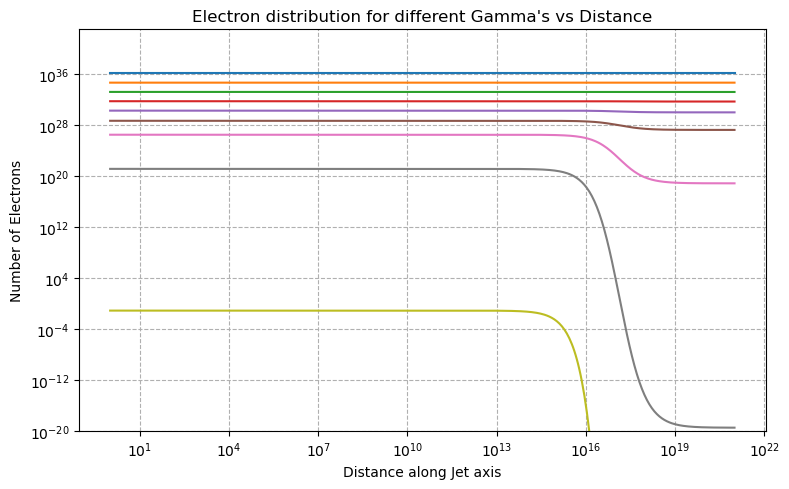

In [133]:
#Total number of electrons vs Lorentz factor 
plt.figure(figsize=(8,5))
for i, N_e_gamma in enumerate((n0[:,::60].T)*np.exp((-cooling[:,::60].T).value)):
    plt.loglog(jet.x, N_e_gamma, label =f'gamma = {jet.gamma_e[60*i]}' )
plt.xlabel("Distance along Jet axis")
plt.ylabel("Number of Electrons")
plt.title("Electron distribution for different Gamma's vs Distance")
plt.grid(True, which='both', ls='--')
#plt.xlim(10,1e4)#
plt.ylim(1e-20,1e43)
plt.tight_layout()
#plt.legend()
plt.show()

# Validating Dermer formula with Cotter and Potter's Formula
Integrating Dermer's equation for Synchrotron power across frequencies to check if it matches with Cotter and Potter's formula for Synchrotron power


In [12]:
nu_obs = np.logspace(3, 20, 1000) * u.Hz

# Dermer's Appraoch vs Cotter's Approach
Comparison between Synchrotron Power integrated over all frequencies. P_total_cotter overestimates by a little due to the assumption of all frequencies emitted at a particular frequency making the edges a bit sharper, compared to Dermer's Approach

In [13]:
#Dermer's Method
syn = Synchrotron(jet)

In [ ]:
flux = syn.flux_obs(nu_obs)
syn.evaluate_attenuation()

In [ ]:
sed_ssa = syn.sed_flux(nu_obs, ssa=True)
sed_nossa = syn.sed_flux(nu_obs, ssa=False)

In [19]:
#Cotter and Potter's Approach to Calculate P_sync over all frequencies
prefactor = (sigma_T.cgs * c.cgs) / (6*np.pi)
n = jet.N_e_xg
B = jet.B_x[:, None]
R = jet.R_x[:, None]
int_x = np.trapz(n * (B**2), jet.x,axis=0)
int_y = np.trapz(jet.gamma_e**2 * int_x, jet.gamma_e)
P_total_cotter = (prefactor * int_y)

# SED

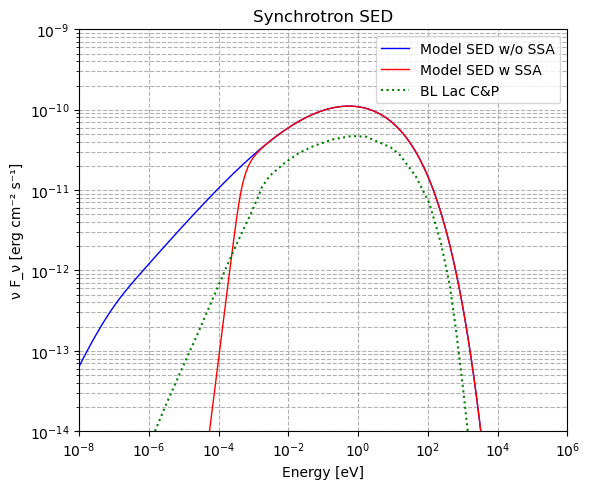

In [21]:
# Data for the SED model of Synchrotron no-losses in Potter and Cotter in Figure 3 
x = [
    0.0003131660307862803, 0.0008840541623107365, 0.0029160081428143986, 0.001735547961136756,
    0.0014102489162420165, 0.0010879770097760172, 0.00781551761898938, 0.019888020057617743,
    0.048049640295616425, 0.1758208691205636, 0.6433550350871309, 1.7243273563482122,
    8.614126945081937, 16.05586850963554, 45.3250224803085, 109.50567327768607,
    238.4870429629985, 422.0385406871394, 639.1956383150009, 968.0894625777796,
    1392.0728770831072, 0.0000014950230456510178, 0.0000030912978018310354, 0.000007866375035417703,
    0.000027328746886507512, 0.00005093804274539881, 0.0001168437895408067
]

# Power / Flux data
y = [
    2.040490199884694e-12, 5.3169639633078265e-12, 1.503111337089843e-11, 1.08492128602697e-11,
    8.495785518249259e-12, 6.6528671251731555e-12, 2.1691180377984993e-11, 2.8852070927376698e-11,
    3.4659557108295606e-11, 4.249311650934016e-11, 4.705073061902792e-11, 4.6101686610606826e-11,
    3.396045117358661e-11, 2.7141154583473827e-11, 1.472792598364928e-11, 6.929596780336585e-12,
    2.169118037798499e-12, 6.652867125173156e-13, 1.842836161290166e-13, 4.163600255825478e-14,
    1.0000000000000041e-14, 1.0000000000000041e-14, 2.125365508342596e-14, 5.316963963307826e-14,
    1.769243507691091e-13, 3.327544666280575e-13, 7.672833112592147e-13
]

# Optional: sort the data by frequency for a smoother curve
sorted_data = sorted(zip(x, y))
x_sorted, y_sorted = zip(*sorted_data)
# Plot SED
plt.figure(figsize=(6,5))
plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_no_ssa, color='blue', lw=1, label='Model SED w/o SSA')
#plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_cotter, color='green', lw=2, label='Model SED')
plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_ssa, color='red', lw=1, label='Model SED w SSA')
# Overlay updated data points
plt.loglog(x_sorted, y_sorted, linestyle='dotted', color='green',label='BL Lac C&P')

plt.xlabel("Energy [eV]")
plt.ylabel("ν F_ν [erg cm⁻² s⁻¹]")
plt.title("Synchrotron SED")
plt.grid(True, which='both', ls='--')
plt.ylim(1e-14, 1e-9)
plt.xlim(1e-8,1e6)
plt.legend()
plt.tight_layout()
plt.show()

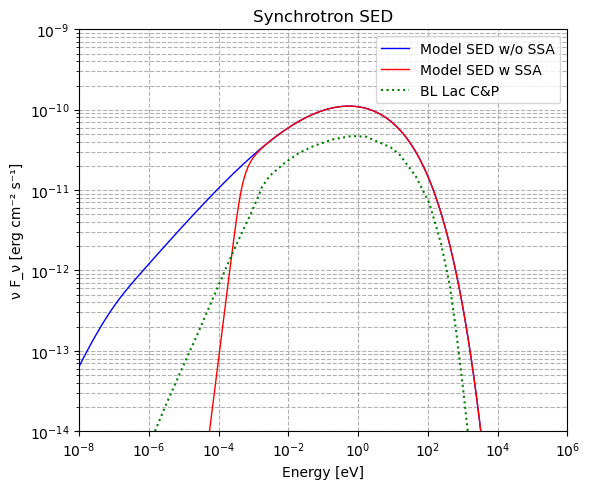

In [22]:
# Data for the SED model of Synchrotron no-losses in Potter and Cotter in Figure 3 
x = [
    0.0003131660307862803, 0.0008840541623107365, 0.0029160081428143986, 0.001735547961136756,
    0.0014102489162420165, 0.0010879770097760172, 0.00781551761898938, 0.019888020057617743,
    0.048049640295616425, 0.1758208691205636, 0.6433550350871309, 1.7243273563482122,
    8.614126945081937, 16.05586850963554, 45.3250224803085, 109.50567327768607,
    238.4870429629985, 422.0385406871394, 639.1956383150009, 968.0894625777796,
    1392.0728770831072, 0.0000014950230456510178, 0.0000030912978018310354, 0.000007866375035417703,
    0.000027328746886507512, 0.00005093804274539881, 0.0001168437895408067
]

# Power / Flux data
y = [
    2.040490199884694e-12, 5.3169639633078265e-12, 1.503111337089843e-11, 1.08492128602697e-11,
    8.495785518249259e-12, 6.6528671251731555e-12, 2.1691180377984993e-11, 2.8852070927376698e-11,
    3.4659557108295606e-11, 4.249311650934016e-11, 4.705073061902792e-11, 4.6101686610606826e-11,
    3.396045117358661e-11, 2.7141154583473827e-11, 1.472792598364928e-11, 6.929596780336585e-12,
    2.169118037798499e-12, 6.652867125173156e-13, 1.842836161290166e-13, 4.163600255825478e-14,
    1.0000000000000041e-14, 1.0000000000000041e-14, 2.125365508342596e-14, 5.316963963307826e-14,
    1.769243507691091e-13, 3.327544666280575e-13, 7.672833112592147e-13
]

# Optional: sort the data by frequency for a smoother curve
sorted_data = sorted(zip(x, y))
x_sorted, y_sorted = zip(*sorted_data)
# Plot SED
plt.figure(figsize=(6,5))
plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_no_ssa, color='blue', lw=1, label='Model SED w/o SSA')
#plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_cotter, color='green', lw=2, label='Model SED')
plt.loglog((nu_obs).to(u.eV, equivalencies=u.spectral()), sed_ssa, color='red', lw=1, label='Model SED w SSA')
# Overlay updated data points
plt.loglog(x_sorted, y_sorted, linestyle='dotted', color='green',label='BL Lac C&P')

plt.xlabel("Energy [eV]")
plt.ylabel("ν F_ν [erg cm⁻² s⁻¹]")
plt.title("Synchrotron SED")
plt.grid(True, which='both', ls='--')
plt.ylim(1e-14, 1e-9)
plt.xlim(1e-8,1e6)
plt.legend()
plt.tight_layout()
plt.show()